In [ ]:
import math
import sys
import warnings
warnings.filterwarnings('ignore')

dokumanlar= [
    """Yapay zekâ yarışında rekabet giderek kızışırken neredeyse hemen her hafta bir yapay zekâ modelinin yeni güncellemesini görür olduk.
    Bu hafta Anthropic en güçlüsü olarak tanımladığı Claude Fable 5 dil modelini duyurdu. Firmanın Opus katmanının da üzerine konumlandırdığı
    Mythos yapay zekâ modeli ilk olarak Nisan ayında Claude Mythos Preview olarak test sürecine başlamış ve sadece ABD hükümetiyle yürütülen
    Project Glasswing kapsamında seçili savunma ortaklarına açılmıştı. Claude Fable 5 ise Mythos sınıfına ait ancak ama güvenlik filtreleriyle
    herkesin kullanımına açılan bir model olmuş. Şirket, Fable 5'in yazılım mühendisliği, yoğun bilgi işlem faaliyetleri, görsel anlama ve
    bilimsel araştırma gibi alanlarda neredeyse tüm test kriterlerinde sektörün en iyisi konumunda olduğunu iddia ediyor. Anthropic, bu denli
    güçlü bir modeli kamuoyuna sunarken güvenlik konusunda da yeni bir yaklaşım benimsedi. Siber güvenlik, biyoloji, kimya ve distilasyon gibi
    yüksek riskli alanlarda model, yanıt vermek yerine devreye giriyor ve ilgili sorular Claude Opus 4.8'e yönlendiriliyor. Şirkete göre bu
    filtreler ortalama olarak oturumların yüzde beşinden azında devreye giriyor; böylece zararsız sorulara yanlışlıkla müdahale etme riski
    minimuma indiriliyor. Fable 5'in pratikte ne anlama geldiğini gösteren dikkat çekici örnekler de paylaşıldı. Stripe, erken test sürecinde
    Fable 5'in aylarca sürecek mühendislik çalışmalarını günler içinde tamamladığını bildirdi; 50 milyon satırlık bir Ruby kod tabanında, tüm
    bir ekibin iki ayda bitirebileceği bir geçiş işlemini model tek bir günde gerçekleştirdi. Wharton akademisyeni ve yapay zekâ araştırmacısı
    Ethan Mollick ise yaptığı testlerde Fable 5'in bugüne kadar kullandığı tüm kamuya açık modelleri belirgin bir farkla geride bıraktığını
    kamuoyuyla paylaştı. Claude Fable 5 dil modeli Claude Pro üyelerine 22 Haziran tarihine kadar deneme amaçlı sunulmuş durumda.
    """
]

def tokenize(text):
    return text.lower().split()

tokenize_kucuk = [tokenize(d) for d in dokumanlar]
print("Tokenize edilmiş dokümanlar:")
for i, d in enumerate(tokenize_kucuk):
    print(f"  Doküman {i+1}: {d}")

Tokenize edilmiş dokümanlar:
  Doküman 1: ['yapay', 'zekâ', 'yarışında', 'rekabet', 'giderek', 'kızışırken', 'neredeyse', 'hemen', 'her', 'hafta', 'bir', 'yapay', 'zekâ', 'modelinin', 'yeni', 'güncellemesini', 'görür', 'olduk.', 'bu', 'hafta', 'anthropic', 'en', 'güçlüsü', 'olarak', 'tanımladığı', 'claude', 'fable', '5', 'dil', 'modelini', 'duyurdu.', 'firmanın', 'opus', 'katmanının', 'da', 'üzerine', 'konumlandırdığı', 'mythos', 'yapay', 'zekâ', 'modeli', 'ilk', 'olarak', 'nisan', 'ayında', 'claude', 'mythos', 'preview', 'olarak', 'test', 'sürecine', 'başlamış', 've', 'sadece', 'abd', 'hükümetiyle', 'yürütülen', 'project', 'glasswing', 'kapsamında', 'seçili', 'savunma', 'ortaklarına', 'açılmıştı.', 'claude', 'fable', '5', 'ise', 'mythos', 'sınıfına', 'ait', 'ancak', 'ama', 'güvenlik', 'filtreleriyle', 'herkesin', 'kullanımına', 'açılan', 'bir', 'model', 'olmuş.', 'şirket,', 'fable', "5'in", 'yazılım', 'mühendisliği,', 'yoğun', 'bilgi', 'işlem', 'faaliyetleri,', 'görsel', 'anlama', 've

In [ ]:
def tf(term, tokenize_doc):
    count = tokenize_doc.count(term)
    return count / len(tokenize_doc) if len(tokenize_doc) > 0 else 0

def idf(term, tokenize_dokumanlar):
    doc_count = sum(1 for doc in tokenize_dokumanlar if term in doc)
    return math.log(len(tokenize_dokumanlar) / (1 + doc_count)) + 1

print("TF-IDF Değerleri:\n")
for i, doc in enumerate(tokenize_kucuk):
    print(f"--- Doküman {i+1}: '{dokumanlar[i]}' ---")
    for term in sorted(set(doc)):
        tf_val = tf(term, doc)
        idf_val = idf(term, tokenize_kucuk)
        tfidf_val = tf_val * idf_val
        print(f"  '{term}' -> TF: {tf_val:.4f}, IDF: {idf_val:.4f}, TF-IDF: {tfidf_val:.4f}")
    print()

TF-IDF Değerleri:

--- Doküman 1: 'Yapay zekâ yarışında rekabet giderek kızışırken neredeyse hemen her hafta bir yapay zekâ modelinin yeni güncellemesini görür olduk. 
    Bu hafta Anthropic en güçlüsü olarak tanımladığı Claude Fable 5 dil modelini duyurdu. Firmanın Opus katmanının da üzerine konumlandırdığı 
    Mythos yapay zekâ modeli ilk olarak Nisan ayında Claude Mythos Preview olarak test sürecine başlamış ve sadece ABD hükümetiyle yürütülen 
    Project Glasswing kapsamında seçili savunma ortaklarına açılmıştı. Claude Fable 5 ise Mythos sınıfına ait ancak ama güvenlik filtreleriyle
    herkesin kullanımına açılan bir model olmuş. Şirket, Fable 5'in yazılım mühendisliği, yoğun bilgi işlem faaliyetleri, görsel anlama ve 
    bilimsel araştırma gibi alanlarda neredeyse tüm test kriterlerinde sektörün en iyisi konumunda olduğunu iddia ediyor. Anthropic, bu denli 
    güçlü bir modeli kamuoyuna sunarken güvenlik konusunda da yeni bir yaklaşım benimsedi. Siber güvenlik, biyoloji, kimy

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

vectorizer = TfidfVectorizer()
tfidf_matrisi = vectorizer.fit_transform(dokumanlar)

df = pd.DataFrame(
    tfidf_matrisi.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=[f"Doküman {i+1}" for i in range(len(dokumanlar))]
)
df

,22,50,abd,ait,akademisyeni,alanlarda,ama,amaçlı,ancak,anlama,...,yüzde,zararsız,zekâ,çalışmalarını,çekici,örnekler,üyelerine,üzerine,şirket,şirkete
Doküman 1,0.043153,0.043153,0.043153,0.043153,0.043153,0.086306,0.043153,0.043153,0.043153,0.086306,...,0.043153,0.043153,0.172613,0.043153,0.043153,0.043153,0.043153,0.043153,0.043153,0.043153


In [ ]:
print("Her Dokümanda En Yüksek TF-IDF Skoruna Sahip Kelime:\n")
for i, doc in enumerate(dokumanlar):
    satir = df.iloc[i]
    en_iyi = satir.idxmax()
    skor = satir.max()
    print(f"Doküman {i+1}: '{doc}'")
    print(f"  -> En önemli kelime: '{en_iyi}' (skor: {skor:.4f})\n")

Her Dokümanda En Yüksek TF-IDF Skoruna Sahip Kelime:

Doküman 1: 'Yapay zekâ yarışında rekabet giderek kızışırken neredeyse hemen her hafta bir yapay zekâ modelinin yeni güncellemesini görür olduk. 
    Bu hafta Anthropic en güçlüsü olarak tanımladığı Claude Fable 5 dil modelini duyurdu. Firmanın Opus katmanının da üzerine konumlandırdığı 
    Mythos yapay zekâ modeli ilk olarak Nisan ayında Claude Mythos Preview olarak test sürecine başlamış ve sadece ABD hükümetiyle yürütülen 
    Project Glasswing kapsamında seçili savunma ortaklarına açılmıştı. Claude Fable 5 ise Mythos sınıfına ait ancak ama güvenlik filtreleriyle
    herkesin kullanımına açılan bir model olmuş. Şirket, Fable 5'in yazılım mühendisliği, yoğun bilgi işlem faaliyetleri, görsel anlama ve 
    bilimsel araştırma gibi alanlarda neredeyse tüm test kriterlerinde sektörün en iyisi konumunda olduğunu iddia ediyor. Anthropic, bu denli 
    güçlü bir modeli kamuoyuna sunarken güvenlik konusunda da yeni bir yaklaşım benimsedi.

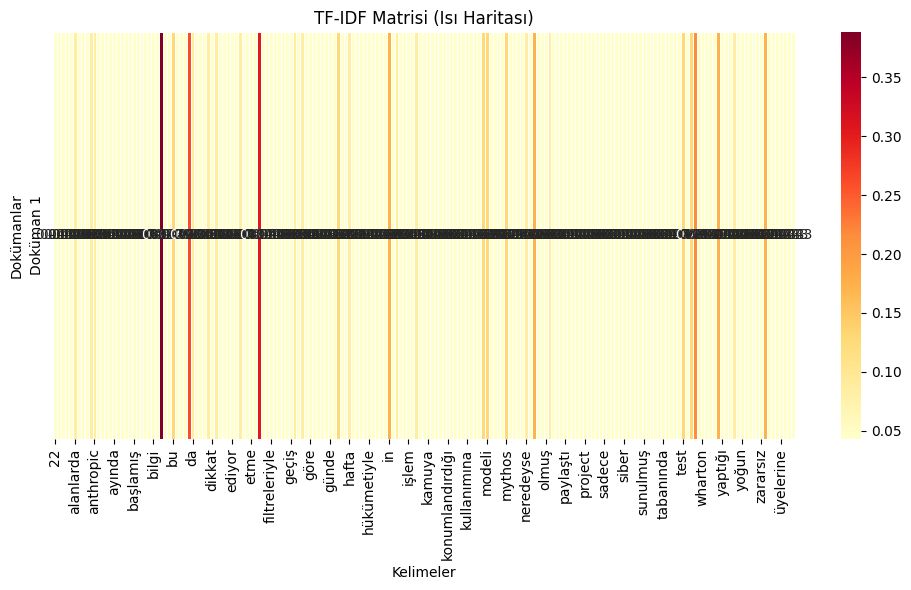

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(df, annot=True, cmap="YlOrRd", fmt=".3f", linewidths=0.5)
plt.title("TF-IDF Matrisi (Isı Haritası)")
plt.xlabel("Kelimeler")
plt.ylabel("Dokümanlar")
plt.tight_layout()
plt.show()

In [ ]:
# ÖRNEK: Anlamsal ilişkinin TF-IDF ile yakalanamaması
print("=" * 70)
print("PROBLEM 1: Anlamsal İlişki (Semantics)")
print("=" * 70)

uzun_metin = """Yapay zekâ yarışında rekabet giderek kızışırken neredeyse hemen her hafta bir yapay zekâ modelinin yeni güncellemesini görür olduk.
    Bu hafta Anthropic en güçlüsü olarak tanımladığı Claude Fable 5 dil modelini duyurdu. Firmanın Opus katmanının da üzerine konumlandırdığı
    Mythos yapay zekâ modeli ilk olarak Nisan ayında Claude Mythos Preview olarak test sürecine başlamış ve sadece ABD hükümetiyle yürütülen
    Project Glasswing kapsamında seçili savunma ortaklarına açılmıştı. Claude Fable 5 ise Mythos sınıfına ait ancak ama güvenlik filtreleriyle
    herkesin kullanımına açılan bir model olmuş. Şirket, Fable 5'in yazılım mühendisliği, yoğun bilgi işlem faaliyetleri, görsel anlama ve
    bilimsel araştırma gibi alanlarda neredeyse tüm test kriterlerinde sektörün en iyisi konumunda olduğunu iddia ediyor. Anthropic, bu denli
    güçlü bir modeli kamuoyuna sunarken güvenlik konusunda da yeni bir yaklaşım benimsedi. Siber güvenlik, biyoloji, kimya ve distilasyon gibi
    yüksek riskli alanlarda model, yanıt vermek yerine devreye giriyor ve ilgili sorular Claude Opus 4.8'e yönlendiriliyor. Şirkete göre bu
    filtreler ortalama olarak oturumların yüzde beşinden azında devreye giriyor; böylece zararsız sorulara yanlışlıkla müdahale etme riski
    minimuma indiriliyor. Fable 5'in pratikte ne anlama geldiğini gösteren dikkat çekici örnekler de paylaşıldı. Stripe, erken test sürecinde
    Fable 5'in aylarca sürecek mühendislik çalışmalarını günler içinde tamamladığını bildirdi; 50 milyon satırlık bir Ruby kod tabanında, tüm
    bir ekibin iki ayda bitirebileceği bir geçiş işlemini model tek bir günde gerçekleştirdi. Wharton akademisyeni ve yapay zekâ araştırmacısı
    Ethan Mollick ise yaptığı testlerde Fable 5'in bugüne kadar kullandığı tüm kamuya açık modelleri belirgin bir farkla geride bıraktığını
    kamuoyuyla paylaştı. Claude Fable 5 dil modeli Claude Pro üyelerine 22 Haziran tarihine kadar deneme amaçlı sunulmuş durumda."""

# Metni cümlelere ayırıp ilk 3 cümleyi alalım
cumleler = [c.strip() + "." for c in uzun_metin.split(".") if len(c.strip()) > 10]
dok_semantik = cumleler[:3]

v = TfidfVectorizer()
m = v.fit_transform(dok_semantik)
df_sem = pd.DataFrame(m.toarray(), columns=v.get_feature_names_out(),
                      index=[f"Cümle {i+1}" for i in range(len(dok_semantik))])

print("\nTF-IDF Vektörleri (İlk 3 Cümle):")
display(df_sem)

from sklearn.metrics.pairwise import cosine_similarity

benzerlik = cosine_similarity(m[0:1], m[1:3])[0]
print(f"\nKosinüs Benzerlikleri:")
print(f"  'Cümle 1' vs 'Cümle 2' : {benzerlik[0]:.4f}")
print(f"  'Cümle 1' vs 'Cümle 3' : {benzerlik[1]:.4f}")
print(f"\nTF-IDF, kelimelerin birebir eşleşmesine (lexical overlap) bakar.")
print(f"Cümle 1 ile diğer cümleler arasındaki benzerlik, sadece ortak kelimelere ('yapay', 'zekâ', 'hafta' vb.) göre hesaplanır.")
print(f"Eş anlamlı veya anlamsal olarak yakın kelimeler kullanılsa bile (örneğin 'model' yerine 'algoritma'), ortak kelime olmadığı sürece TF-IDF bu anlamsal bağı yakalayamaz.")

PROBLEM 1: Anlamsal İlişki (Semantics)

TF-IDF Vektörleri (İlk 3 Cümle):


,abd,anthropic,ayında,açılmıştı,başlamış,bir,bu,claude,da,dil,...,sürecine,tanımladığı,test,ve,yapay,yarışında,yeni,yürütülen,zekâ,üzerine
Cümle 1,0.000000,0.000000,0.000000,0.000000,0.000000,0.234368,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.356485,0.234368,0.234368,0.000000,0.356485,0.000000
Cümle 2,0.000000,0.305207,0.000000,0.000000,0.000000,0.000000,0.305207,0.232118,0.000000,0.305207,...,0.000000,0.305207,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Cümle 3,0.171376,0.000000,0.171376,0.171376,0.171376,0.000000,0.000000,0.130336,0.171376,0.000000,...,0.171376,0.000000,0.171376,0.171376,0.130336,0.000000,0.000000,0.171376,0.130336,0.171376



Kosinüs Benzerlikleri:
  'Cümle 1' vs 'Cümle 2' : 0.0414
  'Cümle 1' vs 'Cümle 3' : 0.0929

TF-IDF, kelimelerin birebir eşleşmesine (lexical overlap) bakar.
Cümle 1 ile diğer cümleler arasındaki benzerlik, sadece ortak kelimelere ('yapay', 'zekâ', 'hafta' vb.) göre hesaplanır.
Eş anlamlı veya anlamsal olarak yakın kelimeler kullanılsa bile (örneğin 'model' yerine 'algoritma'), ortak kelime olmadığı sürece TF-IDF bu anlamsal bağı yakalayamaz.


In [ ]:
# Karşılaştırma: Uzun metinden türetilmiş eş anlamlı / benzer anlamlı cümleler
dok_es_anlam = [
    "Anthropic şirketi Claude Fable 5 dil modelini duyurdu.",
    "Anthropic firması Claude Fable 5 dil algoritmasını ilan etti.",
    "Siber güvenlik, biyoloji, kimya gibi yüksek riskli alanlarda devreye giriyor."
]

v2 = TfidfVectorizer()
m2 = v2.fit_transform(dok_es_anlam)

b = cosine_similarity(m2[0:1], m2[1:3])[0]
print(f"Cümle 1: '{dok_es_anlam[0]}'")
print(f"Cümle 2: '{dok_es_anlam[1]}'")
print(f"Cümle 3: '{dok_es_anlam[2]}'\n")

print(f"1. Cümle vs 2. Cümle (Eş/Yakın Anlamlı) : {b[0]:.4f}")
print(f"1. Cümle vs 3. Cümle (Farklı Bağlam)    : {b[1]:.4f}")
print()
print("Gördüğünüz gibi, 1. ve 2. cümle neredeyse aynı şeyi ifade etmesine rağmen")
print("farklı kelimeler (şirket/firma, model/algoritma, duyurdu/ilan etti) kullanıldığı için")
print("TF-IDF benzerlik skoru kelimeler birebir örtüşmediği için anlamsal bağı kaçırır.")
print("Çünkü TF-IDF anlama değil, yalnızca aynı yazılışa sahip kelimelere (lexical overlap) bakar.")

Cümle 1: 'Anthropic şirketi Claude Fable 5 dil modelini duyurdu.'
Cümle 2: 'Anthropic firması Claude Fable 5 dil algoritmasını ilan etti.'
Cümle 3: 'Siber güvenlik, biyoloji, kimya gibi yüksek riskli alanlarda devreye giriyor.'

1. Cümle vs 2. Cümle (Eş/Yakın Anlamlı) : 0.3994
1. Cümle vs 3. Cümle (Farklı Bağlam)    : 0.0000

Gördüğünüz gibi, 1. ve 2. cümle neredeyse aynı şeyi ifade etmesine rağmen
farklı kelimeler (şirket/firma, model/algoritma, duyurdu/ilan etti) kullanıldığı için
TF-IDF benzerlik skoru kelimeler birebir örtüşmediği için anlamsal bağı kaçırır.
Çünkü TF-IDF anlama değil, yalnızca aynı yazılışa sahip kelimelere (lexical overlap) bakar.


In [ ]:
print("=" * 70)
print("PROBLEM 2: Bağlam (Context) - Kelime Sırası")
print("=" * 70)

# Uzun metinden türetilmiş, aynı kelimelere ancak farklı sıraya/anlama sahip cümleler
dok_baglam = [
    "Anthropic Claude modelini duyurdu.",
    "Claude Anthropic modelini duyurdu.",
    "Siber güvenlik alanında devreye giriyor."
]

v3 = TfidfVectorizer()
m3 = v3.fit_transform(dok_baglam)
df_baglam = pd.DataFrame(m3.toarray(), columns=v3.get_feature_names_out(),
                         index=[f"Cümle {i+1}" for i in range(len(dok_baglam))])

b2 = cosine_similarity(m3[0:1], m3[1:3])[0]

print("\nTF-IDF Vektörleri:")
display(df_baglam)

print(f"\nCümle 1: '{dok_baglam[0]}'")
print(f"Cümle 2: '{dok_baglam[1]}'")
print(f"Cümle 3: '{dok_baglam[2]}'\n")

print(f"Benzerlik: 1. Cümle vs 2. Cümle: {b2[0]:.4f}")
print(f"Benzerlik: 1. Cümle vs 3. Cümle: {b2[1]:.4f}")
print()
print("İlk iki cümle tamamen aynı kelimelerden oluştuğu için TF-IDF benzerliği 1.0 (tam eşleşme) çıkacaktır.")
print("Oysa birinci cümlede eylemi yapan (özne) Anthropic iken, ikinci cümlede Claude'dur (anlam tamamen farklıdır).")
print("TF-IDF kelime sırasını (ve dolayısıyla kimin ne yaptığını) dikkate almaz, kelimeleri bir 'torba' (Bag of Words) gibi görür.")

PROBLEM 2: Bağlam (Context) - Kelime Sırası

TF-IDF Vektörleri:


,alanında,anthropic,claude,devreye,duyurdu,giriyor,güvenlik,modelini,siber
Cümle 1,0.000000,0.5,0.5,0.000000,0.5,0.000000,0.000000,0.5,0.000000
Cümle 2,0.000000,0.5,0.5,0.000000,0.5,0.000000,0.000000,0.5,0.000000
Cümle 3,0.447214,0.0,0.0,0.447214,0.0,0.447214,0.447214,0.0,0.447214



Cümle 1: 'Anthropic Claude modelini duyurdu.'
Cümle 2: 'Claude Anthropic modelini duyurdu.'
Cümle 3: 'Siber güvenlik alanında devreye giriyor.'

Benzerlik: 1. Cümle vs 2. Cümle: 1.0000
Benzerlik: 1. Cümle vs 3. Cümle: 0.0000

İlk iki cümle tamamen aynı kelimelerden oluştuğu için TF-IDF benzerliği 1.0 (tam eşleşme) çıkacaktır.
Oysa birinci cümlede eylemi yapan (özne) Anthropic iken, ikinci cümlede Claude'dur (anlam tamamen farklıdır).
TF-IDF kelime sırasını (ve dolayısıyla kimin ne yaptığını) dikkate almaz, kelimeleri bir 'torba' (Bag of Words) gibi görür.


In [ ]:
# N-gram'lar kısmi çözüm sunar
print("KISMİ ÇÖZÜM: N-gram (bigram) kullanımı")

v4 = TfidfVectorizer(ngram_range=(1, 2))
m4 = v4.fit_transform(dok_baglam)
df_ngram = pd.DataFrame(m4.toarray(), columns=v4.get_feature_names_out(),
                        index=[f"Cümle {i+1}" for i in range(len(dok_baglam))])

b3 = cosine_similarity(m4[0:1], m4[1:3])[0]

print("\nBigram TF-IDF Vektörleri:")
display(df_ngram)

print(f"\nBigram benzerlik: '{dok_baglam[0]}' vs '{dok_baglam[1]}': {b3[0]:.4f}")
print("Bigram ile 'anthropic claude' ve 'claude anthropic' ikilileri farklı öznitelikler olur,")
print("böylece aynı kelimeleri içerseler de iki cümle daha farklı hale gelir ve benzerlik skoru 1.0'ın altına düşer. Ancak bu da derin bir anlamayı sağlamak için yetersizdir.")

KISMİ ÇÖZÜM: N-gram (bigram) kullanımı

Bigram TF-IDF Vektörleri:


,alanında,alanında devreye,anthropic,anthropic claude,anthropic modelini,claude,claude anthropic,claude modelini,devreye,devreye giriyor,duyurdu,giriyor,güvenlik,güvenlik alanında,modelini,modelini duyurdu,siber,siber güvenlik
Cümle 1,0.000000,0.000000,0.343851,0.452123,0.000000,0.343851,0.000000,0.452123,0.000000,0.000000,0.343851,0.000000,0.000000,0.000000,0.343851,0.343851,0.000000,0.000000
Cümle 2,0.000000,0.000000,0.343851,0.000000,0.452123,0.343851,0.452123,0.000000,0.000000,0.000000,0.343851,0.000000,0.000000,0.000000,0.343851,0.343851,0.000000,0.000000
Cümle 3,0.333333,0.333333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.333333,0.333333,0.000000,0.333333,0.333333,0.333333,0.000000,0.000000,0.333333,0.333333



Bigram benzerlik: 'Anthropic Claude modelini duyurdu.' vs 'Claude Anthropic modelini duyurdu.': 0.5912
Bigram ile 'anthropic claude' ve 'claude anthropic' ikilileri farklı öznitelikler olur,
böylece aynı kelimeleri içerseler de iki cümle daha farklı hale gelir ve benzerlik skoru 1.0'ın altına düşer. Ancak bu da derin bir anlamayı sağlamak için yetersizdir.


In [ ]:
print("=" * 70)
print("PROBLEM 3: Boyutlanabilirlik ve Seyreklik")
print("=" * 70)

# Büyük bir veri seti oluşturalım
import numpy as np
import re
import random

np.random.seed(42)
random.seed(42)

# 1. Uzun metnimizden (Claude Fable 5 bağlamı) temel kelimeleri çıkaralım
temiz_metin = re.sub(r'[^\w\s]', '', uzun_metin.lower())
orijinal_kelimeler = list(set(temiz_metin.split()))

# Sadece 100 kelimeyle seyreklik (sparsity) etkisini tam göremeyiz.
# Bu yüzden Anthropic'in tüm şirket içi yazışmaları, raporları ve
# devasa bir kurumsal arşivi simüle etmek için kelimeleri sentetik olarak çoğaltıyoruz:
temel_kelimeler = []
for kelime in orijinal_kelimeler:
    temel_kelimeler.append(kelime)
    for i in range(1, 200): # Her kelime için 199 ek sentetik terim (örneğin model_1, model_2 vb.)
        temel_kelimeler.append(f"{kelime}_{i}")

# Büyük doküman seti oluştur (10,000 doküman)
NUM_DOCS = 10000
buyuk_dokumanlar = []
for _ in range(NUM_DOCS):
    doc_len = np.random.randint(20, 100)
    # Python'ın yerleşik random modülü listeler üzerinde np.random.choice'tan çok daha hızlı çalışır
    doc = " ".join(random.choices(temel_kelimeler, k=doc_len))
    buyuk_dokumanlar.append(doc)

print(f"Doküman sayısı: {len(buyuk_dokumanlar)}")
print(f"Örnek doküman: '{buyuk_dokumanlar[0][:100]}...'")
print(f"Anthropic/Claude bağlamından genişletilen kelime havuzu: {len(temel_kelimeler)} kelime")

PROBLEM 3: Boyutlanabilirlik ve Seyreklik
Doküman sayısı: 10000
Örnek doküman: 'böylece_26 herkesin_155 test_106 belirgin_126 zekâ_133 firmanın_49 erken_81 açılmıştı_121 yoğun_117 ...'
Anthropic/Claude bağlamından genişletilen kelime havuzu: 38200 kelime


In [ ]:
# Seyreklik ölçümü
print("Anthropic/Claude Sentetik Arşivi Üzerinde Seyreklik (Sparsity) Analizi:\n")

v5 = TfidfVectorizer()
m5 = v5.fit_transform(buyuk_dokumanlar)

vocab_size = m5.shape[1]
toplam_hucre = m5.shape[0] * m5.shape[1]
sifir_olmayan = m5.nnz
seyreklik = 100 * (1 - sifir_olmayan / toplam_hucre)

print(f"Kelime dağarcığı boyutu (Anthropic vocab): {vocab_size}")
print(f"Doküman sayısı: {m5.shape[0]}")
print(f"Matris boyutu: {m5.shape}")
print(f"Toplam hücre sayısı: {toplam_hucre:,}")
print(f"Sıfır olmayan hücre sayısı: {sifir_olmayan:,}")
print(f"Seyreklik yüzdesi: %{seyreklik:.2f}")
print()
print(f"Her dokümanda ortalama sıfır olmayan öznitelik: {sifir_olmayan / m5.shape[0]:.1f}")
print(f"Her dokümanda ortalama sıfır (gereksiz) öznitelik: {(toplam_hucre - sifir_olmayan) / m5.shape[0]:.1f}")

Anthropic/Claude Sentetik Arşivi Üzerinde Seyreklik (Sparsity) Analizi:

Kelime dağarcığı boyutu (Anthropic vocab): 38199
Doküman sayısı: 10000
Matris boyutu: (10000, 38199)
Toplam hücre sayısı: 381,990,000
Sıfır olmayan hücre sayısı: 594,848
Seyreklik yüzdesi: %99.84

Her dokümanda ortalama sıfır olmayan öznitelik: 59.5
Her dokümanda ortalama sıfır (gereksiz) öznitelik: 38139.5


Anthropic/Claude Bağlamında Vocabulary Büyüklüğüne Karşı Seyreklik:

  max_features=  500 -> gerçek boyut=  500, seyreklik=%99.73
  max_features= 2000 -> gerçek boyut= 2000, seyreklik=%99.76
  max_features= 5000 -> gerçek boyut= 5000, seyreklik=%99.78
  max_features=10000 -> gerçek boyut=10000, seyreklik=%99.79
  max_features=20000 -> gerçek boyut=20000, seyreklik=%99.81
  max_features=38000 -> gerçek boyut=38000, seyreklik=%99.84


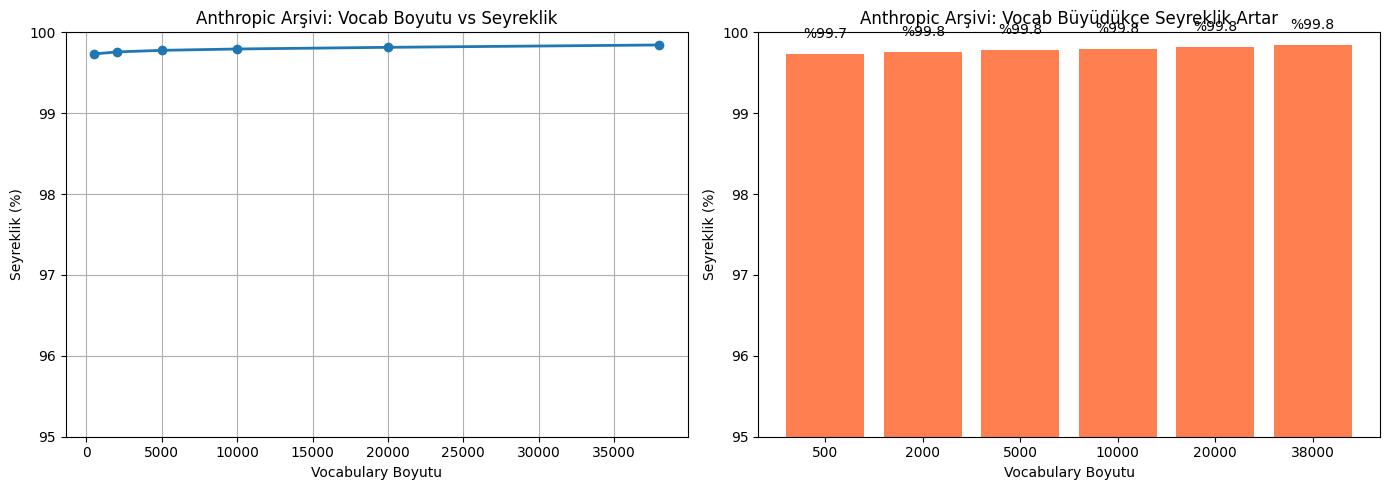

In [ ]:
# Seyrekliğin vocabulary büyüklüğü ile ilişkisi
print("Anthropic/Claude Bağlamında Vocabulary Büyüklüğüne Karşı Seyreklik:\n")

max_features_degerleri = [500, 2000, 5000, 10000, 20000, 38000]
seyreklikler = []
boyutlar = []

for mf in max_features_degerleri:
    v = TfidfVectorizer(max_features=mf)
    m = v.fit_transform(buyuk_dokumanlar)
    toplam = m.shape[0] * m.shape[1]
    nnz = m.nnz
    sey = 100 * (1 - nnz / toplam)
    seyreklikler.append(sey)
    boyutlar.append(m.shape[1])
    print(f"  max_features={mf:5d} -> gerçek boyut={m.shape[1]:5d}, seyreklik=%{sey:.2f}")

# Görselleştir
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(boyutlar, seyreklikler, marker='o', linewidth=2)
axes[0].set_xlabel("Vocabulary Boyutu")
axes[0].set_ylabel("Seyreklik (%)")
axes[0].set_title("Anthropic Arşivi: Vocab Boyutu vs Seyreklik")
axes[0].grid(True)
axes[0].set_ylim(95, 100)

axes[1].bar([str(b) for b in boyutlar], seyreklikler, color='coral')
axes[1].set_xlabel("Vocabulary Boyutu")
axes[1].set_ylabel("Seyreklik (%)")
axes[1].set_title("Anthropic Arşivi: Vocab Büyüdükçe Seyreklik Artar")
axes[1].set_ylim(95, 100)
for i, v in enumerate(seyreklikler):
    axes[1].text(i, v + 0.2, f"%{v:.1f}", ha='center')

plt.tight_layout()
plt.show()

In [ ]:
# Hafıza kullanımı karşılaştırması: Seyrek vs Yoğun matris
print("Anthropic/Claude Arşivi Hafıza Kullanımı: Seyrek (Sparse) vs Yoğun (Dense) Matris\n")

v6 = TfidfVectorizer(max_features=5000)
m_sparse = v6.fit_transform(buyuk_dokumanlar)

# Hafıza hesaplamaları
# Sparse matris: nnz * (8 byte + 4 byte + 4 byte) ≈ nnz * 16 byte
sparse_memory = m_sparse.nnz * 16 / (1024 * 1024)

# Dense matris: shape[0] * shape[1] * 8 byte
dense_memory = m_sparse.shape[0] * m_sparse.shape[1] * 8 / (1024 * 1024)

print(f"Matris boyutu: {m_sparse.shape[0]} x {m_sparse.shape[1]}")
print(f"  Seyrek matris hafızası: {sparse_memory:.2f} MB")
print(f"  Yoğun matris hafızası  : {dense_memory:.2f} MB")
print(f"  Tasarruf               : {dense_memory / sparse_memory:.1f}x daha az hafıza!\n")

print(f"Eğer 1 milyon dokümanlık devasa bir Anthropic veriseti olsaydı (38.200 kelime dağarcığı ile):")
print(f"  Seyrek matris RAM ihtiyacı: yaklaşık ~300 MB")
print(f"  Yoğun (Dense) matris RAM ihtiyacı : 1,000,000 × 38200 × 8 byte ≈ 305,600 MB ≈ 305 GB!")
print(f"İşte TF-IDF matrislerinin RAM'de yoğun (dense) matris olarak saklanamamasının nedeni budur.")

Anthropic/Claude Arşivi Hafıza Kullanımı: Seyrek (Sparse) vs Yoğun (Dense) Matris

Matris boyutu: 10000 x 5000
  Seyrek matris hafızası: 1.70 MB
  Yoğun matris hafızası  : 381.47 MB
  Tasarruf               : 224.6x daha az hafıza!

Eğer 1 milyon dokümanlık devasa bir Anthropic veriseti olsaydı (38.200 kelime dağarcığı ile):
  Seyrek matris RAM ihtiyacı: yaklaşık ~300 MB
  Yoğun (Dense) matris RAM ihtiyacı : 1,000,000 × 38200 × 8 byte ≈ 305,600 MB ≈ 305 GB!
İşte TF-IDF matrislerinin RAM'de yoğun (dense) matris olarak saklanamamasının nedeni budur.


Boyut Laneti Gösterimi: Yüksek Boyutta Mesafe Dağılımı



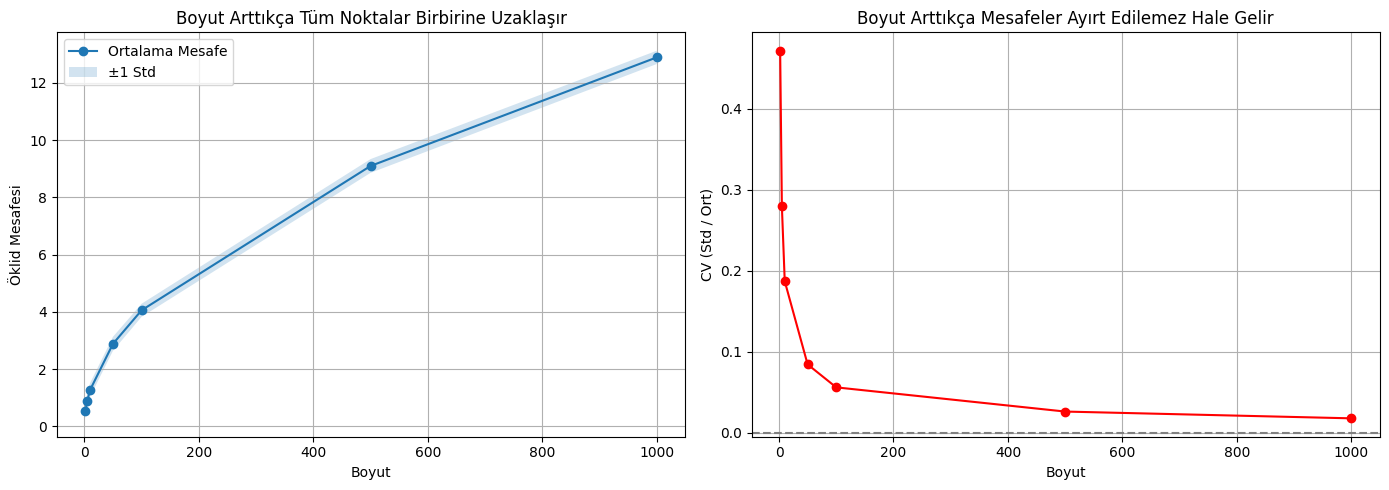

Yorum: Boyut arttıkça tüm noktalar birbirine benzer uzaklıkta olur.
CV değeri 0'a yaklaşır → mesafeler anlamsızlaşır.


In [ ]:
# Boyut laneti: Yüksek boyutta mesafelerin anlamını yitirmesi
print("Boyut Laneti Gösterimi: Yüksek Boyutta Mesafe Dağılımı\n")

from scipy.spatial.distance import pdist

np.random.seed(42)

boyutlar = [2, 5, 10, 50, 100, 500, 1000]
noktalar = 50

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mesafe_ort = []
mesafe_std = []

for dim in boyutlar:
    # Birim hiperküpte rastgele noktalar
    data = np.random.uniform(0, 1, (noktalar, dim))
    mesafeler = pdist(data, 'euclidean')
    mesafe_ort.append(np.mean(mesafeler))
    mesafe_std.append(np.std(mesafeler))

axes[0].plot(boyutlar, mesafe_ort, marker='o', label='Ortalama Mesafe')
axes[0].fill_between(boyutlar,
                     np.array(mesafe_ort) - np.array(mesafe_std),
                     np.array(mesafe_ort) + np.array(mesafe_std),
                     alpha=0.2, label='±1 Std')
axes[0].set_xlabel("Boyut")
axes[0].set_ylabel("Öklid Mesafesi")
axes[0].set_title("Boyut Arttıkça Tüm Noktalar Birbirine Uzaklaşır")
axes[0].legend()
axes[0].grid(True)

# CV (değişim katsayısı) = std / mean → düşükse mesafeler ayırt edilemez
cv = [s / m for m, s in zip(mesafe_ort, mesafe_std)]
axes[1].plot(boyutlar, cv, marker='o', color='red')
axes[1].axhline(y=0, color='gray', linestyle='--')
axes[1].set_xlabel("Boyut")
axes[1].set_ylabel("CV (Std / Ort)")
axes[1].set_title("Boyut Arttıkça Mesafeler Ayırt Edilemez Hale Gelir")
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("Yorum: Boyut arttıkça tüm noktalar birbirine benzer uzaklıkta olur.")
print("CV değeri 0'a yaklaşır → mesafeler anlamsızlaşır.")

In [ ]:
# TF-IDF vs Basit Embedding: Benzerlik Karşılaştırması

from sklearn.decomposition import TruncatedSVD

test_docs = [
    "Anthropic şirketi Claude Fable 5 modelini tanıttı",
    "Anthropic firması Claude Fable 5 algoritmasını duyurdu",
    "Siber güvenlik alanında riskli durumlarda devreye girer"
]

# --- TF-IDF ---
v_tfidf = TfidfVectorizer()
m_tfidf = v_tfidf.fit_transform(test_docs)
vocab = list(v_tfidf.get_feature_names_out())

print("TF-IDF Vektörleri (seyrek, yüksek boyutlu):")
print(f"  Boyut: {m_tfidf.shape[1]}")
print(f"  'şirket/tanıttı' vs 'firma/duyurdu' benzerlik: {cosine_similarity(m_tfidf[0:1], m_tfidf[1:2])[0][0]:.4f}")
print(f"  'şirket/tanıttı' vs 'siber güvenlik'  benzerlik: {cosine_similarity(m_tfidf[0:1], m_tfidf[2:3])[0][0]:.4f}")

# --- SVD ile yoğun vektöre dönüştürme (boyut indirgeme) ---
svd = TruncatedSVD(n_components=2, random_state=42)
m_dense = svd.fit_transform(m_tfidf)

print(f"\nSVD ile 2 boyuta indirgenmiş yoğun vektörler:")
for i, label in enumerate(["Cümle 1 (şirket)", "Cümle 2 (firma)", "Cümle 3 (siber)"]):
    print(f"  {label}: ({m_dense[i][0]:.4f}, {m_dense[i][1]:.4f})")

benzerlik_dense = cosine_similarity(m_dense[0:1], m_dense[1:3])[0]
print(f"\nYoğun vektör benzerlikleri:")
print(f"  'Cümle 1' vs 'Cümle 2': {benzerlik_dense[0]:.4f}")
print(f"  'Cümle 1' vs 'Cümle 3'   : {benzerlik_dense[1]:.4f}")

print(f"\nFark: Yoğunlaştırma sonrası ilk iki cümlenin benzerliği artabilir")
print(f"(ortak kelimeler sayesinde). Ancak bu gerçek bir anlamsal eşleşme değildir.")
print(f"Gerçek embedding yöntemleri (Word2Vec, BERT) bu eşanlamlılık ilişkisini (şirket=firma vb.)")
print(f"çok daha iyi öğrenir ve daha isabetli benzerlik üretir.")

TF-IDF Vektörleri (seyrek, yüksek boyutlu):
  Boyut: 16
  'şirket/tanıttı' vs 'firma/duyurdu' benzerlik: 0.3664
  'şirket/tanıttı' vs 'siber güvenlik'  benzerlik: 0.0000

SVD ile 2 boyuta indirgenmiş yoğun vektörler:
  Cümle 1 (şirket): (0.8266, 0.0000)
  Cümle 2 (firma): (0.8266, -0.0000)
  Cümle 3 (siber): (-0.0000, 1.0000)

Yoğun vektör benzerlikleri:
  'Cümle 1' vs 'Cümle 2': 1.0000
  'Cümle 1' vs 'Cümle 3'   : -0.0000

Fark: Yoğunlaştırma sonrası ilk iki cümlenin benzerliği artabilir
(ortak kelimeler sayesinde). Ancak bu gerçek bir anlamsal eşleşme değildir.
Gerçek embedding yöntemleri (Word2Vec, BERT) bu eşanlamlılık ilişkisini (şirket=firma vb.)
çok daha iyi öğrenir ve daha isabetli benzerlik üretir.


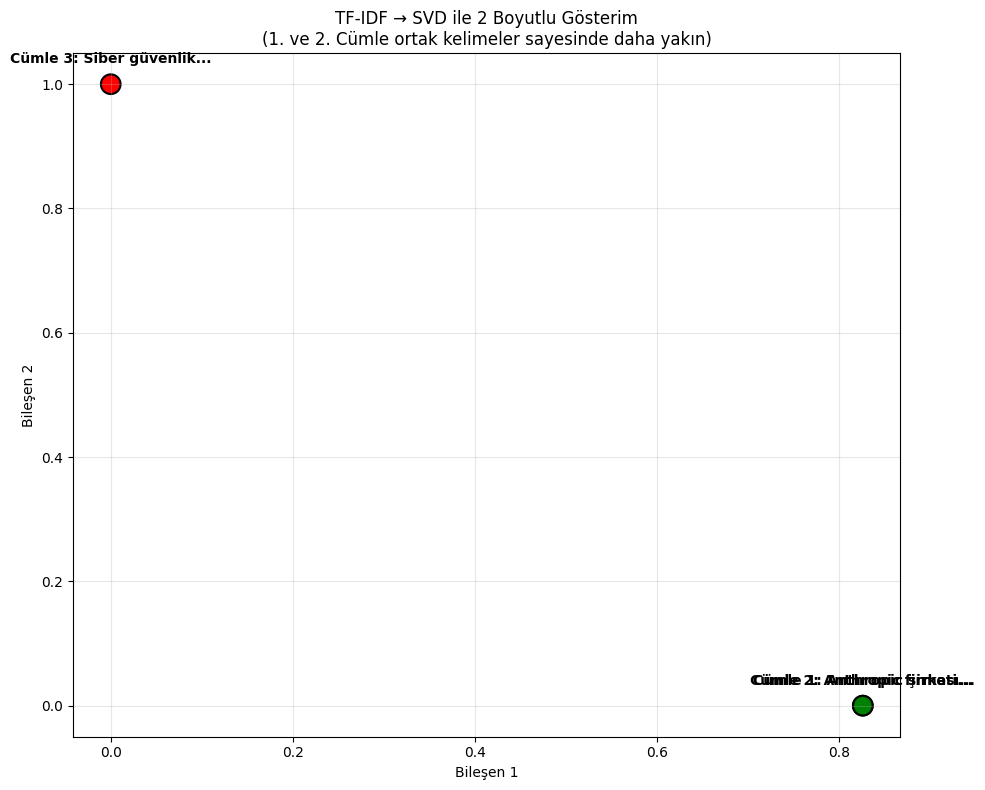

Not: Boyut indirgeme sonrası 1. ve 2. cümle birbirine daha yakın konumlanır.
Ancak bu sadece ortak kelimelerden (Anthropic, Claude vb.) kaynaklanır.
Gerçek semantik anlayış (şirket/firma eşanlamlılığı) için Word2Vec veya BERT gibi modeller gereklidir.


In [ ]:
# Görselleştirme: 2D düzlemde kelime konumları
plt.figure(figsize=(10, 8))

etiketler = [
    "Cümle 1: Anthropic şirketi...",
    "Cümle 2: Anthropic firması...",
    "Cümle 3: Siber güvenlik..."
]
renkler = ['blue', 'green', 'red']

plt.scatter(m_dense[:, 0], m_dense[:, 1], c=renkler, s=200, edgecolors='black', linewidth=1.5)
for i, label in enumerate(etiketler):
    plt.annotate(f"{label}", (m_dense[i, 0], m_dense[i, 1]),
                 textcoords="offset points", xytext=(0, 15), ha='center', fontsize=10, fontweight='bold')

plt.title("TF-IDF → SVD ile 2 Boyutlu Gösterim\n(1. ve 2. Cümle ortak kelimeler sayesinde daha yakın)")
plt.xlabel("Bileşen 1")
plt.ylabel("Bileşen 2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Not: Boyut indirgeme sonrası 1. ve 2. cümle birbirine daha yakın konumlanır.")
print("Ancak bu sadece ortak kelimelerden (Anthropic, Claude vb.) kaynaklanır.")
print("Gerçek semantik anlayış (şirket/firma eşanlamlılığı) için Word2Vec veya BERT gibi modeller gereklidir.")